# ***PT-F2 Model Comparison: Multinomial Logistic Regression vs Linear SVM***

This notebook implements the PT-F2 exercise using the wine dataset from scikit-learn.
It follows the lecture topics on model generalization, training issues, and the risks of overfitting
and underfitting by using 10-fold cross-validation and a held-out test set.

We compare a probabilistic model (Multinomial Logistic Regression using softmax) with a
geometric model (Linear SVM maximizing the margin), and tune the cost/regularization parameter $C$.

# ***Cell 1 - Imports and version checks***
| Line | Description |
| --- | --- |
| 1 | Imports `numpy` as `np` for array math. |
| 2 | Imports `pandas` as `pd` for tabular data. |
| 3 | Imports `matplotlib.pyplot` as `plt` for plotting. |
| 4 | Blank line for readability. |
| 5 | Imports the wine dataset loader. |
| 6 | Imports train/test split and cross-validation utilities. |
| 7 | Imports `Pipeline` to chain preprocessing and modeling. |
| 8 | Imports `StandardScaler` for feature normalization. |
| 9 | Imports `LogisticRegression` for multinomial classification. |
| 10 | Imports `LinearSVC` for linear SVM classification. |
| 11 | Starts the metrics import block. |
| 12 | Imports `accuracy_score` and `confusion_matrix`. |
| 13 | Imports `precision_recall_fscore_support`. |
| 14 | Imports `cohen_kappa_score`. |
| 15 | Imports `ConfusionMatrixDisplay` for plots. |
| 16 | Closes the metrics import block. |
| 17 | Blank line for readability. |
| 18 | Imports `sklearn` to report its version. |
| 19 | Blank line for readability. |
| 20 | Prints the scikit-learn version. |
| 21 | Prints the NumPy version. |
| 22 | Prints the pandas version. |

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_recall_fscore_support,
    cohen_kappa_score,
    ConfusionMatrixDisplay
)

import sklearn

print('sklearn:', sklearn.__version__)
print('numpy:', np.__version__)
print('pandas:', pd.__version__)

sklearn: 1.6.1
numpy: 2.0.2
pandas: 2.2.2


# ***Cell 2 - Load dataset and split***
| Line | Description |
| --- | --- |
| 1 | Comment indicating the data-loading step. |
| 2 | Loads the wine dataset into `wine`. |
| 3 | Assigns feature matrix to `X`. |
| 4 | Assigns class labels to `y`. |
| 5 | Stores feature names for later labeling. |
| 6 | Blank line for readability. |
| 7 | Comment describing the 80/20 split. |
| 8 | Calls `train_test_split` to create train and test sets. |
| 9 | Passes data, test size, stratification, and seed. |
| 10 | Closes the split call. |
| 11 | Blank line for readability. |
| 12 | Outputs shapes of train and test arrays. |

In [2]:
# Load data
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names

# 80/20 split (80% training for CV, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((142, 13), (36, 13))

# ***Cell 3 - Pipelines, grids, and tuning***
| Line | Description |
| --- | --- |
| 1 | Comment describing leakage-safe pipelines. |
| 2 | Defines the `make_mlr` factory function. |
| 3 | Sets the solver to `lbfgs`. |
| 4 | Sets the maximum iterations. |
| 5 | Sets the random seed for reproducibility. |
| 6 | Returns the configured `LogisticRegression` instance. |
| 7 | Blank line for readability. |
| 8 | Starts the MLR pipeline definition. |
| 9 | Adds `StandardScaler` to the pipeline. |
| 10 | Adds the MLR model to the pipeline. |
| 11 | Closes the MLR pipeline list. |
| 12 | Blank line for readability. |
| 13 | Starts the SVM pipeline definition. |
| 14 | Adds `StandardScaler` to the SVM pipeline. |
| 15 | Adds the `LinearSVC` model to the pipeline. |
| 16 | Sets `max_iter` for convergence. |
| 17 | Sets the random seed. |
| 18 | Closes the `LinearSVC` call. |
| 19 | Closes the SVM pipeline list. |
| 20 | Blank line for readability. |
| 21 | Comment introducing the C grid. |
| 22 | Creates log-spaced `C` values. |
| 23 | Blank line for readability. |
| 24 | Comment introducing grid search tuning. |
| 25 | Starts the MLR parameter grid. |
| 26 | Adds the `C` grid to MLR. |
| 27 | Adds tolerance values to MLR. |
| 28 | Adds class-weight options to MLR. |
| 29 | Closes the MLR grid. |
| 30 | Blank line for readability. |
| 31 | Starts the SVM parameter grid. |
| 32 | Adds the `C` grid to SVM. |
| 33 | Adds tolerance values to SVM. |
| 34 | Adds loss function options to SVM. |
| 35 | Adds class-weight options to SVM. |
| 36 | Closes the SVM grid. |
| 37 | Blank line for readability. |
| 38 | Defines 10-fold stratified CV with shuffling. |
| 39 | Blank line for readability. |
| 40 | Starts the MLR `GridSearchCV` definition. |
| 41 | Supplies the MLR pipeline. |
| 42 | Supplies the MLR parameter grid. |
| 43 | Sets the CV splitter. |
| 44 | Enables parallel processing. |
| 45 | Uses accuracy as the scoring metric. |
| 46 | Retains train scores for diagnostics. |
| 47 | Closes the MLR grid search call. |
| 48 | Blank line for readability. |
| 49 | Starts the SVM `GridSearchCV` definition. |
| 50 | Supplies the SVM pipeline. |
| 51 | Supplies the SVM parameter grid. |
| 52 | Sets the CV splitter. |
| 53 | Enables parallel processing. |
| 54 | Uses accuracy as the scoring metric. |
| 55 | Retains train scores for diagnostics. |
| 56 | Closes the SVM grid search call. |
| 57 | Blank line for readability. |
| 58 | Fits the MLR grid on the training data. |
| 59 | Fits the SVM grid on the training data. |
| 60 | Blank line for readability. |
| 61 | Outputs best parameters for both models. |

In [12]:
# Pipelines to prevent data leakage
def make_mlr():
    return LogisticRegression(
        solver='lbfgs',
        max_iter=5000,
        random_state=42
    )

mlr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', make_mlr())
])

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC(
        max_iter=10000,
        random_state=42
    ))
])

# C values to test (log-spaced)
c_values = np.logspace(-4, 4, 17)

# GridSearchCV with additional parameter tuning
mlr_param_grid = {
    'model__C': c_values,
    'model__tol': [1e-4, 1e-3, 1e-2],
    'model__class_weight': [None, 'balanced']
}

svm_param_grid = {
    'model__C': c_values,
    'model__tol': [1e-4, 1e-3, 1e-2],
    'model__loss': ['hinge', 'squared_hinge'],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

mlr_grid = GridSearchCV(
    mlr_pipe,
    mlr_param_grid,
    cv=cv,
    n_jobs=-1,
    scoring='accuracy',
    return_train_score=True
)

svm_grid = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=cv,
    n_jobs=-1,
    scoring='accuracy',
    return_train_score=True
)

mlr_grid.fit(X_train, y_train)
svm_grid.fit(X_train, y_train)

mlr_grid.best_params_, svm_grid.best_params_

({'model__C': np.float64(0.01),
  'model__class_weight': None,
  'model__tol': 0.0001},
 {'model__C': np.float64(3.1622776601683795),
  'model__class_weight': None,
  'model__loss': 'hinge',
  'model__tol': 0.0001})

# ***Cell 4 - Build the experiment log***
| Line | Description |
| --- | --- |
| 1 | Comment describing CV result extraction. |
| 2 | Converts MLR CV results into a DataFrame. |
| 3 | Converts SVM CV results into a DataFrame. |
| 4 | Blank line for readability. |
| 5 | Adds a model label for MLR rows. |
| 6 | Adds a model label for SVM rows. |
| 7 | Blank line for readability. |
| 8 | Comment describing column alignment. |
| 9 | Checks if MLR has a `loss` column. |
| 10 | Inserts a `loss` column with `None` for MLR. |
| 11 | Blank line for readability. |
| 12 | Starts the list of columns to keep. |
| 13 | Keeps the model label. |
| 14 | Keeps the `C` parameter. |
| 15 | Keeps the tolerance parameter. |
| 16 | Keeps the class-weight parameter. |
| 17 | Keeps the loss parameter. |
| 18 | Keeps mean CV accuracy. |
| 19 | Keeps CV accuracy standard deviation. |
| 20 | Keeps mean training accuracy. |
| 21 | Keeps training accuracy standard deviation. |
| 22 | Closes the column list. |
| 23 | Blank line for readability. |
| 24 | Starts concatenation of MLR and SVM logs. |
| 25 | Adds MLR rows in the selected column order. |
| 26 | Adds SVM rows in the selected column order. |
| 27 | Closes the concatenation with `ignore_index=True`. |
| 28 | Blank line for readability. |
| 29 | Starts a rename map for report-friendly names. |
| 30 | Renames `param_model__C` to `C`. |
| 31 | Renames `param_model__tol` to `tol`. |
| 32 | Renames `param_model__class_weight` to `class_weight`. |
| 33 | Renames `param_model__loss` to `loss`. |
| 34 | Renames `mean_test_score` to `mean_cv_accuracy`. |
| 35 | Renames `std_test_score` to `std_cv_accuracy`. |
| 36 | Renames `mean_train_score` to `mean_train_accuracy`. |
| 37 | Renames `std_train_score` to `std_train_accuracy`. |
| 38 | Applies the rename in place. |
| 39 | Blank line for readability. |
| 40 | Writes the log to `experiment_log.xlsx`. |
| 41 | Displays the first rows for verification. |

In [5]:
# Collect full CV results and save experiment log
mlr_results = pd.DataFrame(mlr_grid.cv_results_)
svm_results = pd.DataFrame(svm_grid.cv_results_)

mlr_results['model'] = 'MLR'
svm_results['model'] = 'LinearSVM'

# Add missing columns for alignment across models
if 'param_model__loss' not in mlr_results.columns:
    mlr_results['param_model__loss'] = None

log_cols = [
    'model',
    'param_model__C',
    'param_model__tol',
    'param_model__class_weight',
    'param_model__loss',
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'std_train_score'
 ]

experiment_log = pd.concat([
    mlr_results[log_cols],
    svm_results[log_cols]
], ignore_index=True)

experiment_log.rename(columns={
    'param_model__C': 'C',
    'param_model__tol': 'tol',
    'param_model__class_weight': 'class_weight',
    'param_model__loss': 'loss',
    'mean_test_score': 'mean_cv_accuracy',
    'std_test_score': 'std_cv_accuracy',
    'mean_train_score': 'mean_train_accuracy',
    'std_train_score': 'std_train_accuracy'
}, inplace=True)

experiment_log.to_excel('experiment_log.xlsx', index=False)
experiment_log.head()

,model,C,tol,class_weight,loss,mean_cv_accuracy,std_cv_accuracy,mean_train_accuracy,std_train_accuracy
0,MLR,0.0001,0.0001,None,None,0.401429,0.030938,0.401409,0.003384
1,MLR,0.0001,0.0010,None,None,0.401429,0.030938,0.401409,0.003384
2,MLR,0.0001,0.0100,None,None,0.401429,0.030938,0.401409,0.003384
3,MLR,0.0001,0.0001,balanced,None,0.937143,0.048506,0.938201,0.008778
4,MLR,0.0001,0.0010,balanced,None,0.909048,0.054187,0.919402,0.014016


# ***Cell 5 - C vs mean CV accuracy plot***
| Line | Description |
| --- | --- |
| 1 | Comment describing the plot objective. |
| 2 | Starts a grouped aggregation expression. |
| 3 | References the experiment log. |
| 4 | Groups by model and `C`, then selects `mean_cv_accuracy`. |
| 5 | Takes the maximum accuracy per group. |
| 6 | Closes the grouped expression. |
| 7 | Blank line for readability. |
| 8 | Creates a figure with a defined size. |
| 9 | Iterates over each model subset. |
| 10 | Plots accuracy versus `C` with markers. |
| 11 | Blank line for readability. |
| 12 | Sets a log scale on the x-axis. |
| 13 | Labels the x-axis. |
| 14 | Labels the y-axis. |
| 15 | Adds the plot title. |
| 16 | Adds the legend. |
| 17 | Adds a grid for readability. |
| 18 | Adjusts layout to avoid clipping. |
| 19 | Renders the plot. |

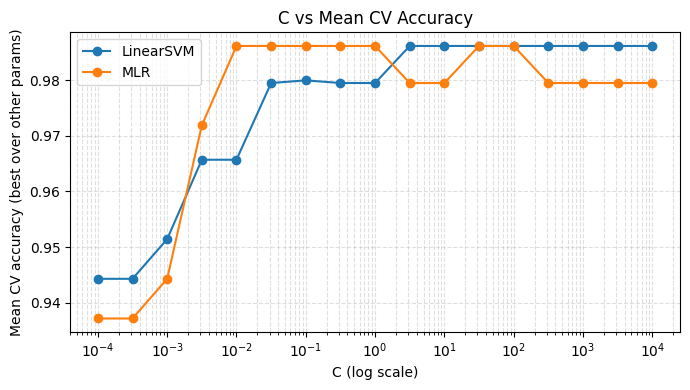

In [6]:
# C vs mean CV accuracy (best over other params)
plot_df = (
    experiment_log
    .groupby(['model', 'C'], as_index=False)['mean_cv_accuracy']
    .max()
 )

plt.figure(figsize=(7, 4))
for model, df in plot_df.groupby('model'):
    plt.plot(df['C'], df['mean_cv_accuracy'], marker='o', label=model)

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('Mean CV accuracy (best over other params)')
plt.title('C vs Mean CV Accuracy')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ***Cell 6 - Model evaluation helper***
| Line | Description |
| --- | --- |
| 1 | Defines the evaluation function. |
| 2 | Predicts labels on the test set. |
| 3 | Computes the confusion matrix. |
| 4 | Blank line for readability. |
| 5 | Starts precision, recall, and F1 computation. |
| 6 | Uses weighted averaging for class imbalance. |
| 7 | Closes the metric call. |
| 8 | Computes accuracy. |
| 9 | Computes Cohen's kappa. |
| 10 | Blank line for readability. |
| 11 | Starts the metrics dictionary. |
| 12 | Stores the model name. |
| 13 | Stores accuracy. |
| 14 | Stores kappa. |
| 15 | Stores precision. |
| 16 | Stores recall. |
| 17 | Stores F1 score. |
| 18 | Closes the metrics dictionary. |
| 19 | Returns the confusion matrix and metrics. |
| 20 | Blank line for readability. |
| 21 | Retrieves the best MLR estimator. |
| 22 | Retrieves the best SVM estimator. |
| 23 | Blank line for readability. |
| 24 | Evaluates MLR on the test set. |
| 25 | Evaluates SVM on the test set. |
| 26 | Blank line for readability. |
| 27 | Outputs both confusion matrices. |

In [7]:
def evaluate_model(name, estimator, X_test, y_test):
    y_pred = estimator.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted'
    )
    acc = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    metrics = {
        'Model': name,
        'Accuracy': acc,
        'Kappa': kappa,
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    }
    return cm, metrics

mlr_best = mlr_grid.best_estimator_
svm_best = svm_grid.best_estimator_

mlr_cm, mlr_metrics = evaluate_model('MLR', mlr_best, X_test, y_test)
svm_cm, svm_metrics = evaluate_model('LinearSVM', svm_best, X_test, y_test)

mlr_cm, svm_cm

(array([[12,  0,  0],
        [ 0, 14,  0],
        [ 0,  0, 10]]),
 array([[12,  0,  0],
        [ 0, 14,  0],
        [ 0,  1,  9]]))

# ***Cell 7 - Confusion matrix visualization***
| Line | Description |
| --- | --- |
| 1 | Comment describing the visualization. |
| 2 | Creates a 1x2 subplot layout. |
| 3 | Blank line for readability. |
| 4 | Plots the MLR confusion matrix. |
| 5 | Sets axis, color map, and disables color bar. |
| 6 | Closes the plot call. |
| 7 | Sets the title for the MLR panel. |
| 8 | Blank line for readability. |
| 9 | Plots the SVM confusion matrix. |
| 10 | Sets axis, color map, and disables color bar. |
| 11 | Closes the plot call. |
| 12 | Sets the title for the SVM panel. |
| 13 | Blank line for readability. |
| 14 | Adjusts layout to prevent overlap. |
| 15 | Renders the figure. |

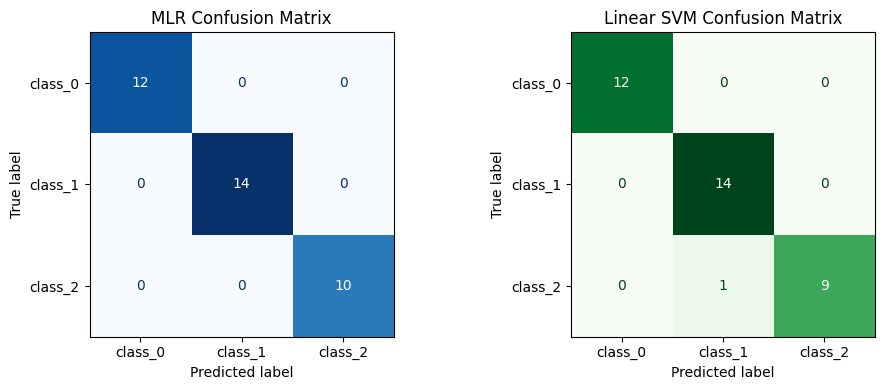

In [8]:
# Confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(mlr_cm, display_labels=wine.target_names).plot(
    ax=axes[0], cmap='Blues', colorbar=False
 )
axes[0].set_title('MLR Confusion Matrix')

ConfusionMatrixDisplay(svm_cm, display_labels=wine.target_names).plot(
    ax=axes[1], cmap='Greens', colorbar=False
 )
axes[1].set_title('Linear SVM Confusion Matrix')

plt.tight_layout()
plt.show()

# ***Cell 8 - Table 1: Best C summary***
| Line | Description |
| --- | --- |
| 1 | Comment describing Table 1. |
| 2 | Reads the MLR CV standard deviation at the best index. |
| 3 | Reads the SVM CV standard deviation at the best index. |
| 4 | Blank line for readability. |
| 5 | Starts the DataFrame construction. |
| 6 | Starts the MLR row. |
| 7 | Sets the model label to MLR. |
| 8 | Inserts the best `C` for MLR. |
| 9 | Inserts mean CV accuracy for MLR. |
| 10 | Inserts CV standard deviation for MLR. |
| 11 | Closes the MLR row. |
| 12 | Starts the SVM row. |
| 13 | Sets the model label to LinearSVM. |
| 14 | Inserts the best `C` for SVM. |
| 15 | Inserts mean CV accuracy for SVM. |
| 16 | Inserts CV standard deviation for SVM. |
| 17 | Closes the SVM row. |
| 18 | Closes the DataFrame list. |
| 19 | Blank line for readability. |
| 20 | Displays the table. |

In [9]:
# Table 1: Hyperparameter Optimization (Best C)
mlr_best_std = mlr_grid.cv_results_['std_test_score'][mlr_grid.best_index_]
svm_best_std = svm_grid.cv_results_['std_test_score'][svm_grid.best_index_]

best_c_table = pd.DataFrame([
    {
        'Model': 'MLR',
        'Best C': mlr_grid.best_params_['model__C'],
        'Mean CV Accuracy': mlr_grid.best_score_,
        'Std CV Accuracy': mlr_best_std
    },
    {
        'Model': 'LinearSVM',
        'Best C': svm_grid.best_params_['model__C'],
        'Mean CV Accuracy': svm_grid.best_score_,
        'Std CV Accuracy': svm_best_std
    }
])

best_c_table

,Model,Best C,Mean CV Accuracy,Std CV Accuracy
0,MLR,0.010000,0.98619,0.02764
1,LinearSVM,3.162278,0.98619,0.02764


# ***Cell 9 - Table 2: Final test metrics***
| Line | Description |
| --- | --- |
| 1 | Comment describing Table 2. |
| 2 | Builds the metrics DataFrame from both models. |
| 3 | Displays the table. |

In [11]:
# Table 2: Final Test Metrics
final_metrics_table = pd.DataFrame([mlr_metrics, svm_metrics])
final_metrics_table

,Model,Accuracy,Kappa,Precision,Recall,F1
0,MLR,1.000000,1.000000,1.000000,1.000000,1.00000
1,LinearSVM,0.972222,0.957746,0.974074,0.972222,0.97197


## Cell 10 - Feature weight comparison plot
| Line | Description |
| --- | --- |
| 1 | Comment describing the feature-weight comparison. |
| 2 | Extracts MLR coefficients. |
| 3 | Extracts SVM coefficients. |
| 4 | Blank line for readability. |
| 5 | Computes mean absolute MLR weights across classes. |
| 6 | Computes mean absolute SVM weights across classes. |
| 7 | Blank line for readability. |
| 8 | Creates x-axis positions for all features. |
| 9 | Sets the bar width for side-by-side plots. |
| 10 | Blank line for readability. |
| 11 | Creates the figure with a specified size. |
| 12 | Plots MLR feature weights. |
| 13 | Plots SVM feature weights. |
| 14 | Adds x-tick labels and rotation. |
| 15 | Labels the y-axis. |
| 16 | Adds the plot title. |
| 17 | Adds the legend. |
| 18 | Applies layout adjustments. |
| 19 | Renders the plot. |

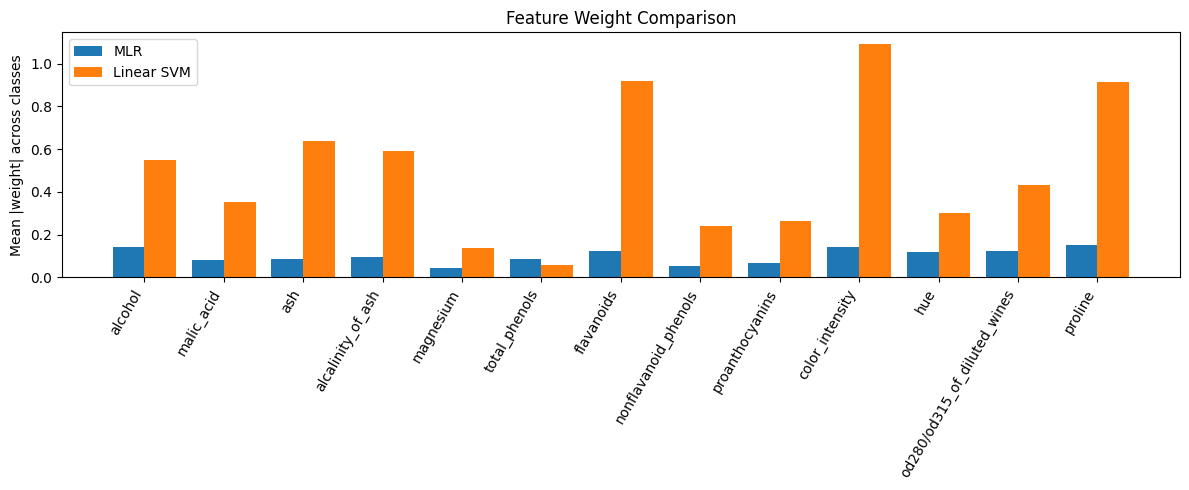

In [10]:
# Feature importance comparison (absolute weights)
mlr_coef = mlr_best.named_steps['model'].coef_
svm_coef = svm_best.named_steps['model'].coef_

mlr_importance = np.mean(np.abs(mlr_coef), axis=0)
svm_importance = np.mean(np.abs(svm_coef), axis=0)

x = np.arange(len(feature_names))
width = 0.4

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, mlr_importance, width, label='MLR')
plt.bar(x + width / 2, svm_importance, width, label='Linear SVM')
plt.xticks(x, feature_names, rotation=60, ha='right')
plt.ylabel('Mean |weight| across classes')
plt.title('Feature Weight Comparison')
plt.legend()
plt.tight_layout()
plt.show()